# Exploratory Data Analysis (EDA)
This notebook is for initial data exploration and visualization.

In [1]:
# notebooks/01_eda.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_DIR = "../data/raw/"

# ── Load each file ──────────────────────────────────────────────
logon  = pd.read_csv(os.path.join(DATA_DIR, "logon.csv"))
device = pd.read_csv(os.path.join(DATA_DIR, "device.csv"))
file   = pd.read_csv(os.path.join(DATA_DIR, "file.csv"))
email  = pd.read_csv(os.path.join(DATA_DIR, "email.csv"))
http   = pd.read_csv(os.path.join(DATA_DIR, "http.csv"))

# Always do this first — understand the shape of your data
for name, df in [("logon", logon), ("device", device), 
                  ("file", file), ("email", email), ("http", http)]:
    print(f"\n{'='*40}")
    print(f"{name}: {df.shape}")
    print(df.dtypes)
    print(df.head(3))
    print(f"Unique users: {df['user'].nunique()}")
    print(f"Date range: {df['date'].min()} → {df['date'].max()}")


logon: (854859, 5)
id          str
date        str
user        str
pc          str
activity    str
dtype: object
                         id                 date     user       pc activity
0  {X1D9-S0ES98JV-5357PWMI}  01/02/2010 06:49:00  NGF0157  PC-6056    Logon
1  {G2B3-L6EJ61GT-2222RKSO}  01/02/2010 06:50:00  LRR0148  PC-4275    Logon
2  {U6Q3-U0WE70UA-3770UREL}  01/02/2010 06:53:04  LRR0148  PC-4124    Logon
Unique users: 1000
Date range: 01/01/2011 00:15:05 → 12/31/2010 23:44:05

device: (405380, 5)
id          str
date        str
user        str
pc          str
activity    str
dtype: object
                         id                 date     user       pc    activity
0  {J1S3-L9UU75BQ-7790ATPL}  01/02/2010 07:21:06  MOH0273  PC-6699     Connect
1  {N7B5-Y7BB27SI-2946PUJK}  01/02/2010 07:37:41  MOH0273  PC-6699  Disconnect
2  {U1V9-Z7XT67KV-5649MYHI}  01/02/2010 07:59:11  HPH0075  PC-2417     Connect
Unique users: 265
Date range: 01/01/2011 08:30:07 → 12/31/2010 23:36:15

file:

In [4]:
# Load ground truth
insiders = pd.read_csv(os.path.join(DATA_DIR, "answers/insiders.csv"))
print(insiders.head(20))
print(f"\nTotal malicious users: {insiders['user'].nunique()}")
print(f"Scenarios: {insiders['scenario'].value_counts()}")

# How many users total?
all_users = logon['user'].unique()
malicious_users = insiders['user'].unique()
benign_users = [u for u in all_users if u not in malicious_users]

print(f"\nTotal users: {len(all_users)}")
print(f"Malicious: {len(malicious_users)} ({len(malicious_users)/len(all_users)*100:.1f}%)")
print(f"Benign: {len(benign_users)}")
# Expect ~5-7% malicious — this is a class imbalance problem

    dataset  scenario             details     user                start  \
0       2.0         1              r2.csv  ONS0995     3/6/2010 1:41:56   
1       3.1         1          r3.1-1.csv  CSF0929  07/01/2010 01:24:58   
2       3.1         2          r3.1-2.csv  CCH0959  08/02/2010 10:34:31   
3       3.2         1          r3.2-1.csv  RCW0822  09/29/2010 21:10:27   
4       3.2         2          r3.2-2.csv  JCE0258  07/12/2010 08:16:02   
5       4.1         1          r4.1-1.csv  ABB0427  08/21/2010 05:20:34   
6       4.1         2          r4.1-2.csv  HFC0492  08/23/2010 10:40:56   
7       4.1         3          r4.1-3.csv  KTW0365  07/08/2010 11:51:00   
8       4.2         1  r4.2-1-AAM0658.csv  AAM0658  10/23/2010 01:34:19   
9       4.2         1  r4.2-1-AJR0932.csv  AJR0932  09/10/2010 19:12:01   
10      4.2         1  r4.2-1-BDV0168.csv  BDV0168  07/30/2010 19:56:44   
11      4.2         1  r4.2-1-BIH0745.csv  BIH0745  07/13/2010 20:15:23   
12      4.2         1  r4

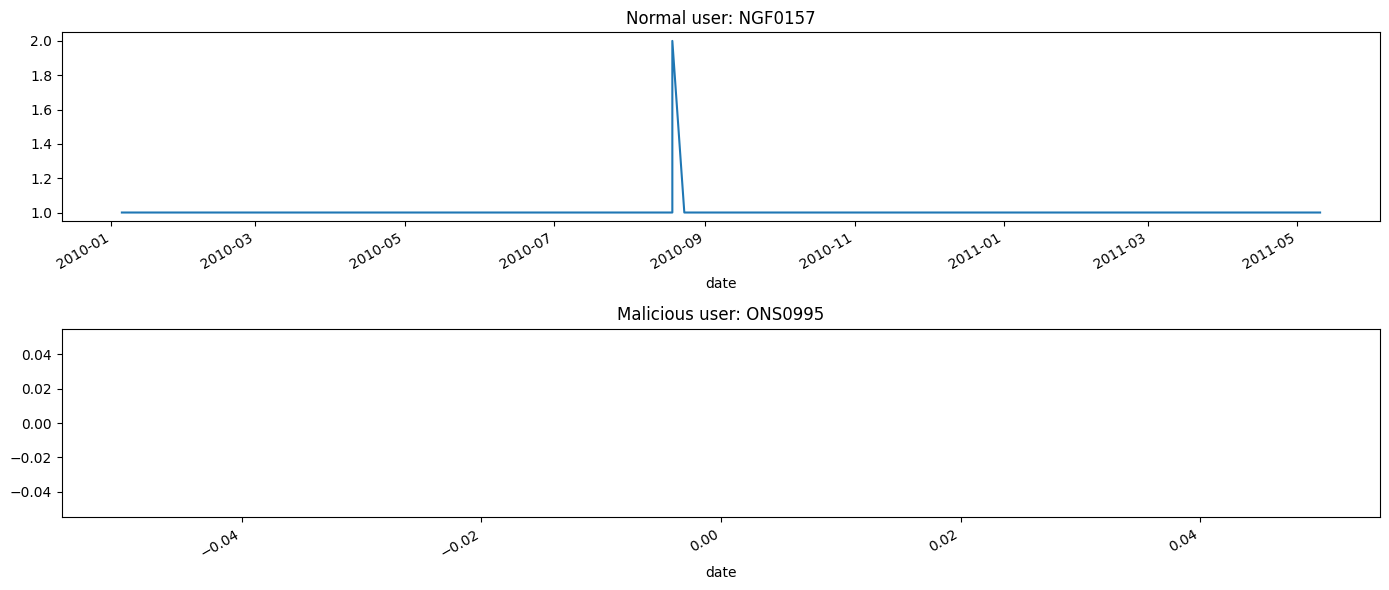

In [5]:
# Visualize a normal user vs a malicious user's daily activity
# Pick one of each and plot their file access counts over time

def get_daily_file_counts(user_id):
    user_files = file[file['user'] == user_id].copy()
    user_files['date'] = pd.to_datetime(user_files['date'])
    return user_files.groupby('date').size()

# Pick one normal, one malicious
normal_user   = benign_users[0]
malicious_user = malicious_users[0]

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
get_daily_file_counts(normal_user).plot(ax=axes[0], 
                                         title=f"Normal user: {normal_user}")
get_daily_file_counts(malicious_user).plot(ax=axes[1], 
                                            title=f"Malicious user: {malicious_user}",
                                            color='red')
plt.tight_layout()
plt.savefig("../data/processed/eda_file_activity.png")
plt.show()

# You should see: the malicious user has a massive spike
# This is what your model needs to learn to detect